# Phase 4 — technical variance (Goal 2)

**How much of the between-sample variation is the lab, not the person?** This runs
*before* Phase 5 on purpose: its answer sets how much weight the disease findings
can bear. The logic lives in `src/variance.py`; this notebook runs it once end to
end and writes `reports/variance_explained.csv`, `reports/variance_report.md`,
`reports/project_classifier_cv.csv`, `reports/depth_alpha_association.csv` and the
`reports/figures/phase4_*.png` figures.

Five pieces:

1. **Distances** — Bray-Curtis on relative abundance, Aitchison (Euclidean on CLR)
   on the ≥1%-prevalence matrix, on a project-stratified subsample (a full
   116k × 116k matrix is ~100 GB). Each distance is processed and freed before the
   next is built.
2. **Ordination** — PCoA and UMAP, coloured by every technical factor and by
   `disease_label`. The `project`-coloured PCoA is the headline.
3. **Variance partitioning** — marginal PERMANOVA per factor (≥999 permutations)
   plus an adonis-style **sequential** decomposition run both technical-first and
   disease-first, because sequential R² depends on term order.
4. **Negative control** — a **PyTorch** classifier (multinomial logistic
   regression + an MLP) trained to recover a sample's `project` from its
   composition. High accuracy is the *expected* result and the whole point.
5. **Depth vs alpha diversity** — observed richness rises with depth; quantified
   raw vs rarefied.

In [1]:
import gc
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import cohorts as coh
from src import variance as var

REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"

with open(ROOT / "config" / "params.yaml") as f:
    params = yaml.safe_load(f)
SEED = params["seed"]
vcfg = params["variance"]
ccfg = vcfg["classifier"]
DEPTH_BINS = vcfg.get("depth_bins", 5)

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"seed={SEED}  torch={torch.__version__}  device={DEVICE}")
print(f"distance_subsample_n={vcfg['distance_subsample_n']:,}  permutations={vcfg['permutations']}")
print(f"classifier: max_n={ccfg['max_n']:,}  min_project_size={ccfg['min_project_size']}  "
      f"folds={ccfg['cv_folds']}  epochs={ccfg['epochs']}")

seed=42  torch=2.14.0+cpu  device=cpu
distance_subsample_n=7,000  permutations=999
classifier: max_n=40,000  min_project_size=25  folds=5  epochs=15


## Load the QC-passed population

Recomputed from `samples_harmonized.parquet` + `sample_depth.parquet` via the same
`cohorts.apply_qc_filters` Phase 2 / Phase 3 use (cheap, deterministic — not
persisted). `prepare_covariates` then derives `depth_bin` (quantile bins of read
depth) and makes the `bead_beating` / `library_source` blanks explicit levels
("protocol not reported"), not NaN.

In [2]:
harmonized = pd.read_parquet(INTERIM / "samples_harmonized.parquet")
sample_depth = pd.read_parquet(INTERIM / "sample_depth.parquet")

qc, flow = coh.apply_qc_filters(harmonized, sample_depth, params["qc"]["depth_threshold"])
qc = var.prepare_covariates(qc, n_depth_bins=DEPTH_BINS)
del harmonized; gc.collect()
print(f"QC-passed: {len(qc):,} samples across {qc['project'].nunique()} projects")

cov = qc[var.TECHNICAL_FACTORS + [var.BIOLOGICAL_FACTOR]].notna().mean().mul(100).round(1)
print("\nfactor coverage (% non-null in QC-passed):")
print(cov.to_string())

QC-passed: 116,657 samples across 341 projects

factor coverage (% non-null in QC-passed):
project           100.0
amplicon          100.0
kit_family        100.0
instrument        100.0
region            100.0
depth_bin         100.0
library_source    100.0
bead_beating      100.0
disease_label      12.8


## Step 1 — Project-stratified subsample

One project-stratified subsample of the QC-passed population, shared by both
distances and the ordination.

In [3]:
sub_all = var.project_stratified_subsample(qc, vcfg["distance_subsample_n"], SEED)
keys_all = sub_all["sample"].tolist()
print(f"sub_all: {len(sub_all):,} samples, {sub_all['project'].nunique()} projects")
COLOR_BY = var.TECHNICAL_FACTORS + [var.BIOLOGICAL_FACTOR]

sub_all: 7,015 samples, 341 projects


## Step 2 — Bray-Curtis: distance → PCoA → ordination → marginal PERMANOVA

The Bray-Curtis matrix is built on relative abundance, used for its PCoA (incl. the
headline `project`-coloured panel) and its marginal PERMANOVA, then freed before the
Aitchison matrix is built — only one dense n×n matrix is ever resident.

Bray-Curtis: (7015, 7015)  trace(G)=2,584.8  (122s)
PCoA Bray-Curtis proportion explained (PCo1-3): [0.217 0.115 0.087]
marginal PERMANOVA (Bray-Curtis) in 108s
        factor    n  n_groups     R2  pseudo_F     p
       project 7015       341 0.4338   15.0406 0.001
      amplicon 7015        11 0.1108   87.2713 0.001
    kit_family 7015         9 0.0474   43.5622 0.001
    instrument 7015        12 0.0385   25.5160 0.001
        region 7015         8 0.0406   42.3147 0.001
     depth_bin 7015         5 0.0049    8.6597 0.001
library_source 7015         2 0.0023   16.3760 0.001
  bead_beating 7015         3 0.0121   42.8959 0.001


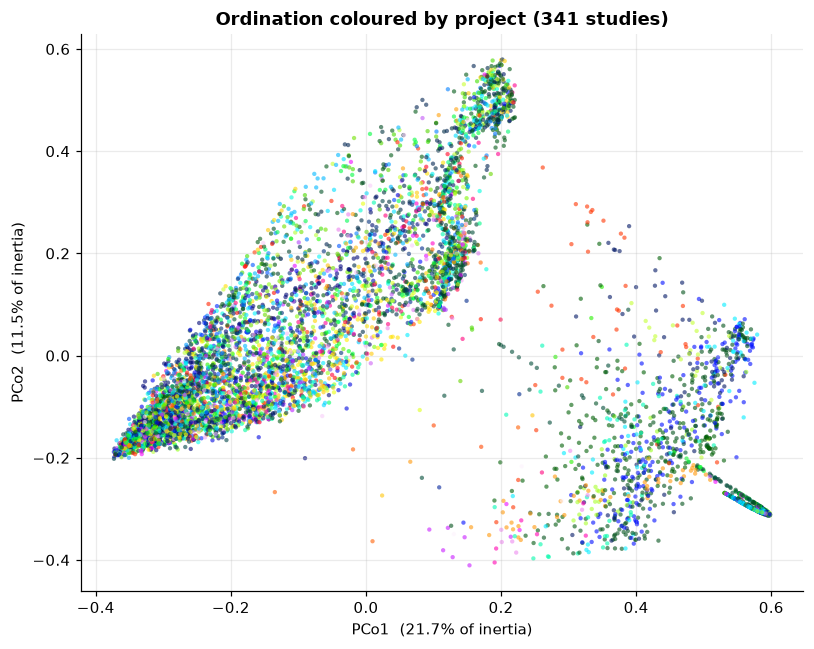

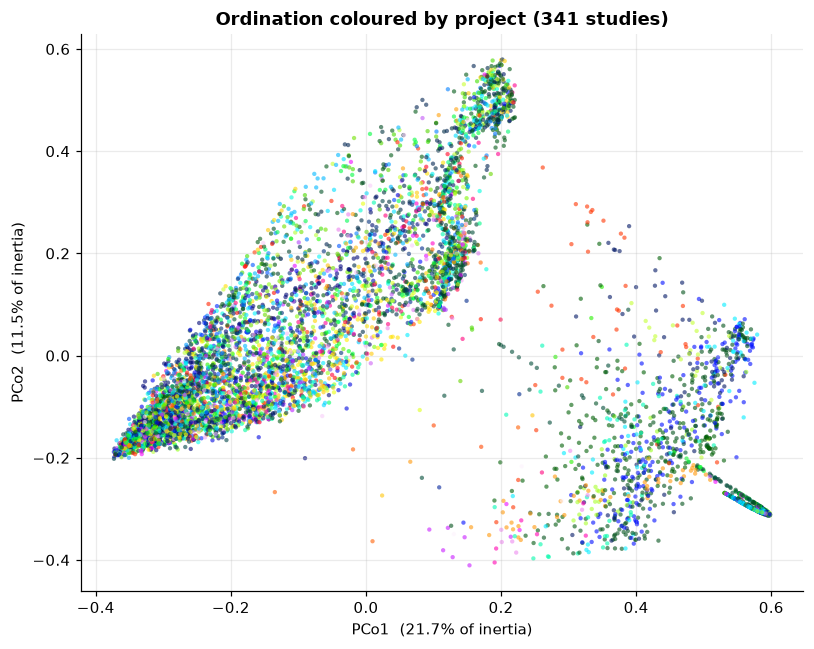

In [4]:
t0 = time.time()
ids_rel, rel, _ = var.load_abundance_subset(PROCESSED / "abund_relative.parquet", keys_all)
keys_bc, rel = var.align(ids_rel, rel, keys_all)
D_bc = var.bray_curtis_matrix(rel)
del rel, ids_rel; gc.collect()
print(f"Bray-Curtis: {D_bc.shape}  trace(G)={var.gower_trace(D_bc):,.1f}  ({time.time()-t0:.0f}s)")

pcoa_bc, prop_bc = var.pcoa_coords(D_bc, keys_bc, n_dims=vcfg["pcoa_dims"], seed=SEED)
print(f"PCoA Bray-Curtis proportion explained (PCo1-3): {np.round(prop_bc, 3)}")

fig = var.plot_ordination_grid(pcoa_bc, qc, COLOR_BY, "PCo1", "PCo2",
                               f"PCoA Bray-Curtis — {len(pcoa_bc):,} samples")
fig.savefig(FIGURES / "phase4_pcoa_braycurtis.png"); plt.close(fig)
headline = var.plot_ordination_headline(pcoa_bc, qc, "PCo1", "PCo2", prop_bc, factor="project")
headline.savefig(FIGURES / "phase4_ordination_headline.png")

t0 = time.time()
mg_bc = var.permanova_marginal(D_bc, keys_bc, qc, var.TECHNICAL_FACTORS,
                               vcfg["permutations"], SEED, "bray_curtis")
del D_bc; gc.collect()
print(f"marginal PERMANOVA (Bray-Curtis) in {time.time()-t0:.0f}s")
print(mg_bc[["factor", "n", "n_groups", "R2", "pseudo_F", "p"]].round(4).to_string(index=False))
headline

## Step 3 — Aitchison: distance → PCoA + UMAP → ordination → marginal PERMANOVA

Aitchison distance is Euclidean distance on CLR coordinates. Same flow as Step 2,
plus a UMAP of the CLR matrix (which is small — ~420 columns).

In [5]:
t0 = time.time()
ids_clr, clr, _ = var.load_abundance_subset(PROCESSED / "abund_clr.parquet", keys_all)
keys_ait, clr = var.align(ids_clr, clr, keys_all)
del ids_clr; gc.collect()
D_ait = var.aitchison_matrix(clr)
print(f"Aitchison: {D_ait.shape}  trace(G)={var.gower_trace(D_ait):,.1f}  "
      f"(CLR subset missing {len(keys_all) - len(keys_ait)} key — the zero-mass sample "
      f"excluded from abund_clr.parquet in Phase 3)  ({time.time()-t0:.0f}s)")

pcoa_ait, prop_ait = var.pcoa_coords(D_ait, keys_ait, n_dims=vcfg["pcoa_dims"], seed=SEED)
print(f"PCoA Aitchison proportion explained (PCo1-3): {np.round(prop_ait, 3)}")

t0 = time.time()
umap_ait = var.umap_coords(clr, keys_ait, seed=SEED,
                           n_neighbors=vcfg["umap_neighbors"], min_dist=vcfg["umap_min_dist"])
del clr; gc.collect()
print(f"UMAP (CLR, euclidean): {umap_ait.shape}  ({time.time()-t0:.0f}s)")

for coords, xy, name in [(pcoa_ait, ("PCo1", "PCo2"), "pcoa_aitchison"),
                         (umap_ait, ("UMAP1", "UMAP2"), "umap_aitchison")]:
    fig = var.plot_ordination_grid(coords, qc, COLOR_BY, xy[0], xy[1],
                                   f"{name} — {len(coords):,} samples")
    fig.savefig(FIGURES / f"phase4_{name}.png"); plt.close(fig)

t0 = time.time()
mg_ait = var.permanova_marginal(D_ait, keys_ait, qc, var.TECHNICAL_FACTORS,
                                vcfg["permutations"], SEED, "aitchison")
del D_ait; gc.collect()
print(f"marginal PERMANOVA (Aitchison) in {time.time()-t0:.0f}s")
mg_ait[["factor", "n", "n_groups", "R2", "pseudo_F", "p"]].round(4)

Aitchison: (7015, 7015)  trace(G)=7,595,229.0  (CLR subset missing 0 key — the zero-mass sample excluded from abund_clr.parquet in Phase 3)  (12s)
PCoA Aitchison proportion explained (PCo1-3): [0.233 0.056 0.037]


c:\Users\Jadrovski\vnp\MicroWave\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP (CLR, euclidean): (7015, 3)  (50s)
marginal PERMANOVA (Aitchison) in 107s


,factor,n,n_groups,R2,pseudo_F,p
0,project,7015,341,0.3942,12.7727,0.001
1,amplicon,7015,11,0.0586,43.6165,0.001
2,kit_family,7015,9,0.0339,30.6955,0.001
3,instrument,7015,12,0.0422,28.0486,0.001
4,region,7015,8,0.0360,37.3984,0.001
5,depth_bin,7015,5,0.0233,41.8633,0.001
6,library_source,7015,2,0.0014,10.0876,0.001
7,bead_beating,7015,3,0.0062,21.7388,0.001


## Step 4 — `disease_label` + sequential decomposition (labelled cohort)

`disease_label` covers only ~13% of the QC-passed set, so it is tested on a separate
project-stratified subsample of `cohort_labeled_all` (`sub_lab`), alongside the
technical factors on the *same* samples. Then the adonis-style **sequential**
decomposition on the Aitchison coordinates of `sub_lab` — exact here, since Aitchison
distance is Euclidean on CLR — run three ways:

- **technical_first** — all technical factors, then `disease_label`
- **disease_first** — `disease_label` first, then the technical factors
- **project_vs_disease** — `project` (the batch itself), then `disease_label`

Sequential R² is order-dependent by construction; each ordering's R² (with Residual)
sums to 1.0 — asserted.

In [6]:
labeled = pd.read_parquet(PROCESSED / "cohort_labeled_all.parquet")
labeled = var.prepare_covariates(labeled, n_depth_bins=DEPTH_BINS)
sub_lab = var.project_stratified_subsample(labeled, vcfg["distance_subsample_n"], SEED)
keys_lab = sub_lab["sample"].tolist()

ids_lc, clr_l, _ = var.load_abundance_subset(PROCESSED / "abund_clr.parquet", keys_lab)
keys_lc, clr_l = var.align(ids_lc, clr_l, keys_lab)
del ids_lc; gc.collect()
D_ait_l = var.aitchison_matrix(clr_l)
print(f"sub_lab: {len(keys_lc):,} labelled samples, {sub_lab['project'].nunique()} projects "
      f"({labeled['disease_label'].value_counts().to_dict()} overall)")

t0 = time.time()
mg_lab = var.permanova_marginal(D_ait_l, keys_lc, labeled,
                                var.TECHNICAL_FACTORS + [var.BIOLOGICAL_FACTOR],
                                vcfg["permutations"], SEED, "aitchison_labeled")
del D_ait_l; gc.collect()
print(f"marginal PERMANOVA (labelled) in {time.time()-t0:.0f}s")

marginal = pd.concat([mg_bc, mg_ait, mg_lab], ignore_index=True)
marginal[["distance", "factor", "n", "n_groups", "R2", "pseudo_F", "p"]].round(4)

sub_lab: 7,001 labelled samples, 48 projects ({'healthy': 9285, 'case': 5669} overall)
marginal PERMANOVA (labelled) in 166s


,distance,factor,n,n_groups,R2,pseudo_F,p
0,bray_curtis,project,7015,341,0.4338,15.0406,0.001
1,bray_curtis,amplicon,7015,11,0.1108,87.2713,0.001
2,bray_curtis,kit_family,7015,9,0.0474,43.5622,0.001
3,bray_curtis,instrument,7015,12,0.0385,25.5160,0.001
4,bray_curtis,region,7015,8,0.0406,42.3147,0.001
5,bray_curtis,depth_bin,7015,5,0.0049,8.6597,0.001
6,bray_curtis,library_source,7015,2,0.0023,16.3760,0.001
7,bray_curtis,bead_beating,7015,3,0.0121,42.8959,0.001
8,aitchison,project,7015,341,0.3942,12.7727,0.001
9,aitchison,amplicon,7015,11,0.0586,43.6165,0.001


In [7]:
TECH = ["amplicon", "kit_family", "instrument", "region", "depth_bin",
        "library_source", "bead_beating"]
coords_l = clr_l - clr_l.mean(axis=0)
del clr_l; gc.collect()

t0 = time.time()
seq_tech = var.dbrda_sequential(coords_l, labeled, keys_lc, TECH + [var.BIOLOGICAL_FACTOR],
                                vcfg["permutations"], SEED, "aitchison", "technical_first")
seq_dis = var.dbrda_sequential(coords_l, labeled, keys_lc, [var.BIOLOGICAL_FACTOR] + TECH,
                               vcfg["permutations"], SEED, "aitchison", "disease_first")
seq_proj = var.dbrda_sequential(coords_l, labeled, keys_lc, ["project", var.BIOLOGICAL_FACTOR],
                                vcfg["permutations"], SEED, "aitchison", "project_vs_disease")
sequential = pd.concat([seq_tech, seq_dis, seq_proj], ignore_index=True)
print(f"sequential decomposition in {time.time()-t0:.0f}s")

r2_sums = sequential.groupby("analysis")["R2"].sum()
print("R² sums per ordering (must be ~1.0):")
print(r2_sums.round(6).to_string())
assert np.allclose(r2_sums.to_numpy(), 1.0, atol=1e-6), "sequential R² must partition the total inertia"
sequential[["distance", "analysis", "term_order", "factor", "df", "R2", "pseudo_F", "p"]].round(4)

sequential decomposition in 207s
R² sums per ordering (must be ~1.0):
analysis
sequential:disease_first         1.0
sequential:project_vs_disease    1.0
sequential:technical_first       1.0


,distance,analysis,term_order,factor,df,R2,pseudo_F,p
0,aitchison,sequential:technical_first,1,amplicon,4,0.0322,68.0733,0.001
1,aitchison,sequential:technical_first,2,kit_family,5,0.0304,51.4620,0.001
2,aitchison,sequential:technical_first,3,instrument,6,0.0534,75.4166,0.001
3,aitchison,sequential:technical_first,4,region,7,0.0146,17.6520,0.001
4,aitchison,sequential:technical_first,5,depth_bin,4,0.0146,30.8804,0.001
5,aitchison,sequential:technical_first,6,library_source,1,0.0093,78.8692,0.001
6,aitchison,sequential:technical_first,7,bead_beating,2,0.0208,87.9829,0.001
7,aitchison,sequential:technical_first,8,disease_label,1,0.0016,13.3951,0.001
8,aitchison,sequential:technical_first,9,Residual,6970,0.8232,NaN,NaN
9,aitchison,sequential:disease_first,1,disease_label,1,0.0097,81.7805,0.001


wrote reports/variance_explained.csv: (46, 12)


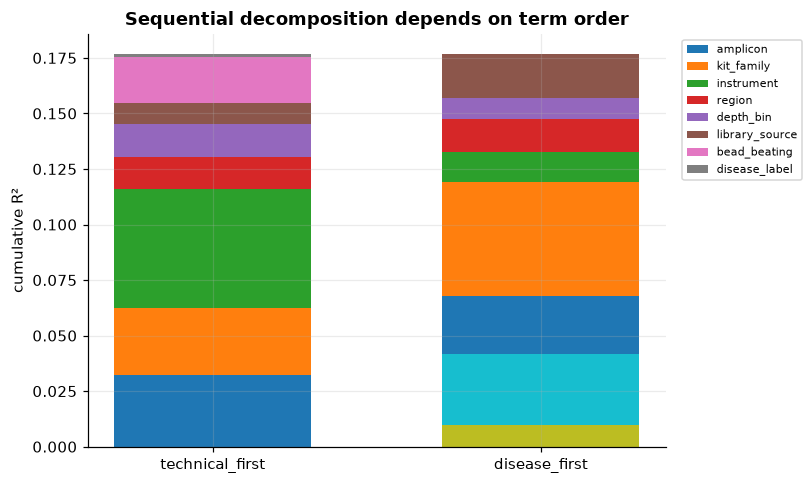

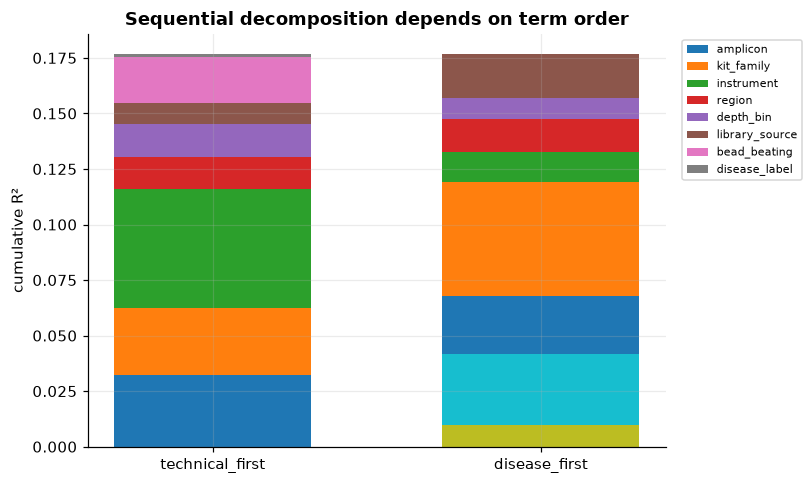

In [8]:
variance_explained = pd.concat([
    marginal.assign(term_order=np.nan),
    sequential,
], ignore_index=True)[
    ["distance", "analysis", "term_order", "factor", "n", "n_groups", "df",
     "R2", "pseudo_F", "p", "n_permutations", "note"]
]
variance_explained.to_csv(REPORTS / "variance_explained.csv", index=False)
print(f"wrote reports/variance_explained.csv: {variance_explained.shape}")

fig = var.plot_variance_bars(marginal); fig.savefig(FIGURES / "phase4_variance_marginal.png"); plt.close(fig)
fig = var.plot_sequential_bars(
    sequential[sequential["analysis"].str.contains("technical_first|disease_first")])
fig.savefig(FIGURES / "phase4_variance_sequential.png")
fig

## Step 5 — Project-predictability classifier (PyTorch)

The negative control. Two PyTorch models — `ProjectLinear` (multinomial logistic
regression, one `nn.Linear`) and `ProjectMLP` (`420 → 256 → 128 → n_projects`, ReLU +
dropout) — trained under stratified k-fold CV to predict a sample's `project` from its
CLR composition. **A high score is the expected, desired result**: it shows the lab
signature is low-dimensional and trivially learnable, which is exactly what a naive
disease classifier would exploit. Reported against the majority-class baseline.

In [9]:
warnings.filterwarnings("ignore")

ids_full, clr_full, _ = var.load_abundance_subset(PROCESSED / "abund_clr.parquet",
                                                  set(qc["sample"]))
pos_by_key = {k: i for i, k in enumerate(ids_full)}
pool = qc[qc["sample"].isin(pos_by_key)][["sample", "project"]]
cls_sub = var.project_stratified_subsample(pool, ccfg["max_n"], SEED)
row_idx = [pos_by_key[k] for k in cls_sub["sample"]]
X_cls = np.ascontiguousarray(clr_full[row_idx])
y_cls = cls_sub["project"].to_numpy()
del clr_full, ids_full; gc.collect()
print(f"classifier population: {X_cls.shape[0]:,} samples x {X_cls.shape[1]} CLR features")

t0 = time.time()
clf_cv, clf_summary = var.run_project_cv(
    X_cls, y_cls, SEED,
    n_splits=ccfg["cv_folds"], epochs=ccfg["epochs"], batch_size=ccfg["batch_size"],
    lr=ccfg["lr"], hidden=tuple(ccfg["hidden"]), min_project_size=ccfg["min_project_size"],
)
del X_cls; gc.collect()
print(f"CV done in {time.time()-t0:.0f}s")
clf_cv.to_csv(REPORTS / "project_classifier_cv.csv", index=False)

print(f"\n{clf_summary}")
print(f"\nmajority-class baseline: {clf_summary['majority_baseline']:.4f}")
print(clf_cv.groupby("model")[["accuracy", "balanced_accuracy", "top5_accuracy"]]
      .agg(["mean", "std"]).round(4).to_string())

classifier population: 40,000 samples x 419 CLR features


project-CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

CV done in 135s

{'n_classes': 267, 'n_samples': 38645, 'n_features': 419, 'majority_baseline': 0.040367447276491136, 'device': 'cpu', 'n_projects_dropped': 74, 'n_samples_dropped': 1355, 'min_project_size': 25}

majority-class baseline: 0.0404
       accuracy         balanced_accuracy         top5_accuracy        
           mean     std              mean     std          mean     std
model                                                                  
linear   0.7576  0.0045            0.6836  0.0079        0.9380  0.0016
mlp      0.7421  0.0034            0.6430  0.0047        0.9404  0.0024


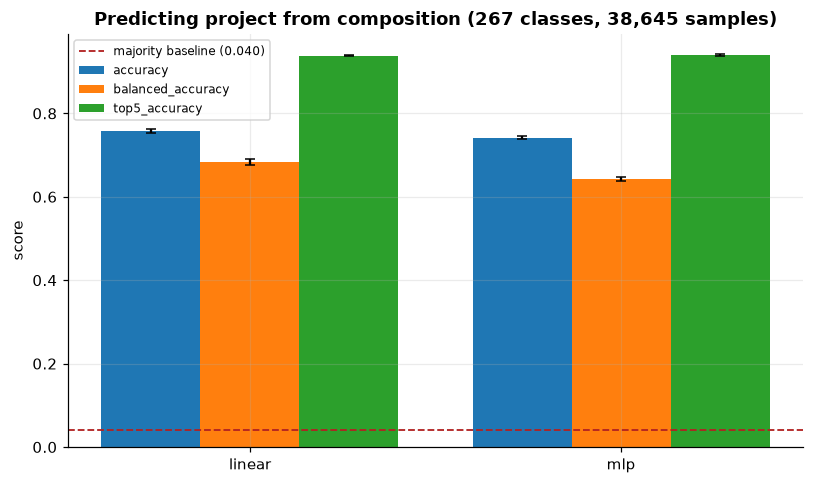

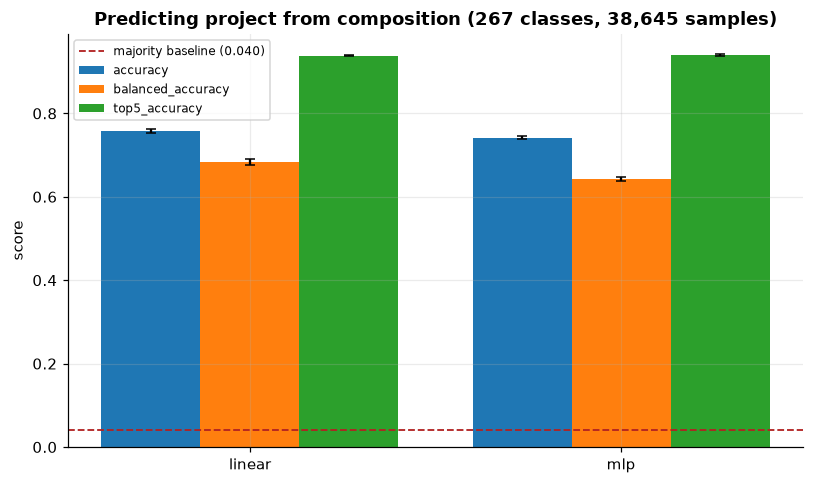

In [10]:
fig = var.plot_project_classifier(clf_cv, clf_summary)
fig.savefig(FIGURES / "phase4_project_classifier.png")
fig

## Step 6 — Depth vs alpha diversity

Observed richness and Shannon vs sequencing depth, on the raw relative-abundance
matrix (depth-varying) and on the rarefied matrix (depth fixed at the QC floor).
The raw association is expected to be clearly positive; rarefaction *reduces* it
but need not erase it (deeper-sequenced samples also tend to come from studies with
genuinely richer communities). Either way it is the case for treating depth as a
covariate in Phase 5. Computed on a project-stratified 30k subsample.

depth-alpha in 41s  (n=29,995)
           metric              column depth_controlled  spearman_rho   p     n
observed richness richness_raw_counts              raw        0.3160 0.0 29995
observed richness   richness_relative              raw        0.3160 0.0 29995
          Shannon    shannon_relative              raw        0.1002 0.0 29995
observed richness   richness_rarefied         rarefied        0.2495 0.0 29995
          Shannon    shannon_rarefied         rarefied        0.0990 0.0 29995


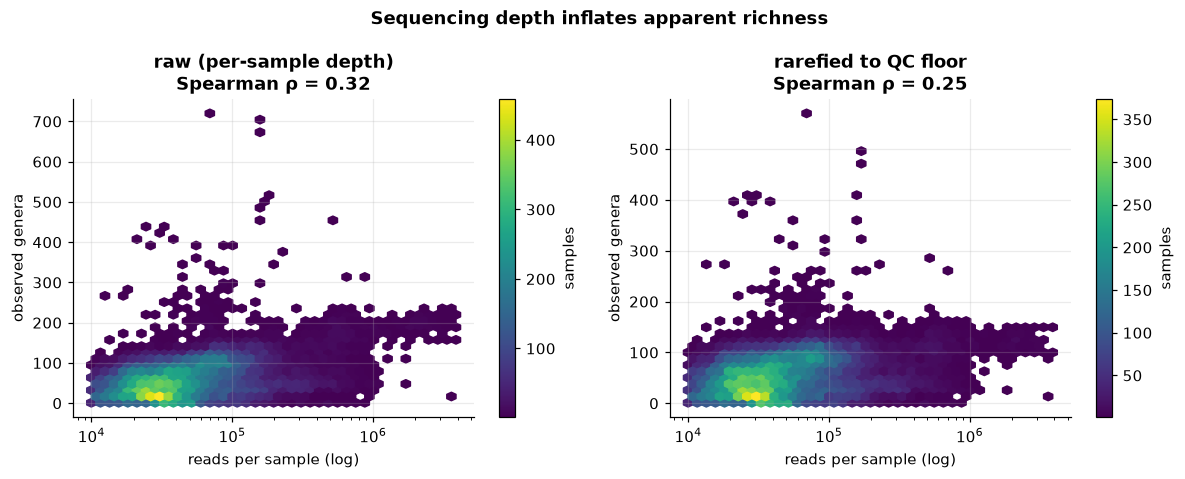

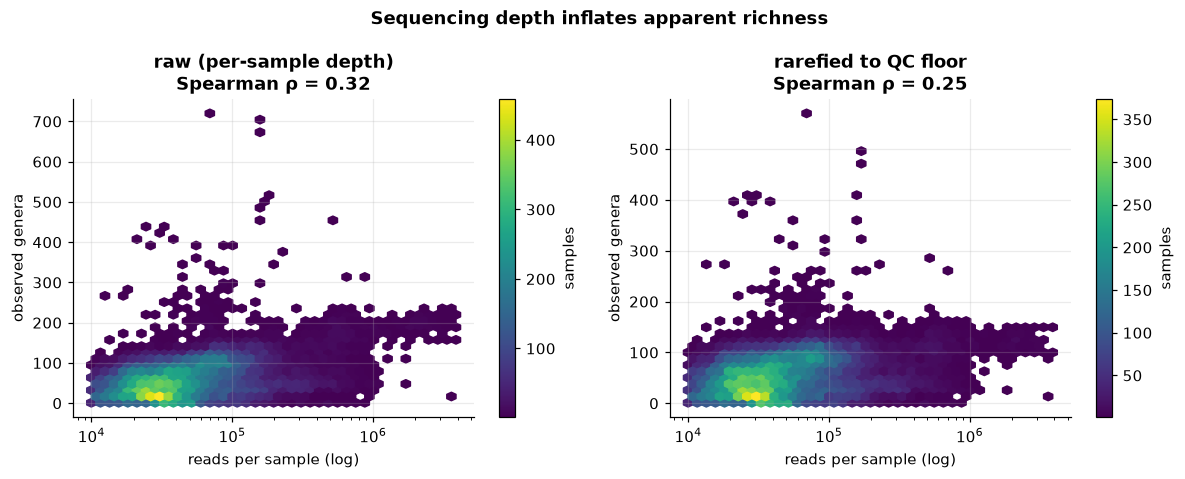

In [11]:
alpha_sub = var.project_stratified_subsample(qc, min(30000, len(qc)), SEED)
t0 = time.time()
alpha_df, alpha_merged = var.depth_alpha_association(
    sample_depth, PROCESSED / "abund_relative.parquet",
    PROCESSED / "abund_rarefied.parquet", set(alpha_sub["sample"]), seed=SEED,
)
print(f"depth-alpha in {time.time()-t0:.0f}s  (n={len(alpha_merged):,})")
alpha_df.to_csv(REPORTS / "depth_alpha_association.csv", index=False)
print(alpha_df.round(4).to_string(index=False))

fig = var.plot_depth_alpha(alpha_merged)
fig.savefig(FIGURES / "phase4_depth_alpha.png")
fig

## Step 7 — Acceptance criteria

IMPLEMENTATION.md Phase 4:

- R² reported for every factor under both term orderings
- permutation count ≥ 999 and recorded
- project-classifier accuracy reported against the majority-class baseline

In [12]:
for f in TECH:
    assert marginal.loc[marginal["factor"] == f, "R2"].notna().any(), f"no marginal R² for {f}"
    for order in ("technical_first", "disease_first"):
        got = sequential[(sequential["analysis"] == f"sequential:{order}") & (sequential["factor"] == f)]
        assert len(got) == 1 and pd.notna(got["R2"].iloc[0]), f"no sequential R² for {f} ({order})"
assert sequential[sequential["factor"] == var.BIOLOGICAL_FACTOR]["R2"].notna().all()

assert (variance_explained["n_permutations"].dropna() >= 999).all(), "permutation count must be >= 999"
assert vcfg["permutations"] >= 999

acc = clf_cv.groupby("model")["accuracy"].mean()
assert "majority_baseline" in clf_summary and clf_summary["majority_baseline"] > 0
assert (acc > clf_summary["majority_baseline"]).all(), "classifier should beat the majority baseline"

print("PASS — every factor has R² marginally and under both orderings")
print(f"PASS — permutations recorded, all >= 999 ({vcfg['permutations']})")
print(f"PASS — classifier accuracy vs majority baseline {clf_summary['majority_baseline']:.4f}:")
for m, a in acc.items():
    print(f"        {m}: {a:.4f}  ({a / clf_summary['majority_baseline']:.0f}x baseline)")

report_md = var.variance_report_md(marginal, sequential, clf_cv, clf_summary, alpha_df)
(REPORTS / "variance_report.md").write_text(report_md, encoding="utf-8")
print("\nwrote reports/variance_report.md")

PASS — every factor has R² marginally and under both orderings
PASS — permutations recorded, all >= 999 (999)
PASS — classifier accuracy vs majority baseline 0.0404:
        linear: 0.7576  (19x baseline)
        mlp: 0.7421  (18x baseline)

wrote reports/variance_report.md


In [13]:
for f in sorted(REPORTS.glob("variance*")) + sorted(REPORTS.glob("project_classifier*")) + \
        sorted(REPORTS.glob("depth_alpha*")) + sorted(FIGURES.glob("phase4_*")):
    print(f"{str(f.relative_to(ROOT)):48s} {f.stat().st_size / 1e3:8.1f} KB")

reports\variance_explained.csv                        4.8 KB
reports\variance_report.md                            4.9 KB
reports\project_classifier_cv.csv                     0.8 KB
reports\depth_alpha_association.csv                   0.4 KB
reports\figures\phase4_depth_alpha.png              156.4 KB
reports\figures\phase4_ordination_headline.png      382.4 KB
reports\figures\phase4_pcoa_aitchison.png          2124.3 KB
reports\figures\phase4_pcoa_braycurtis.png         1693.5 KB
reports\figures\phase4_project_classifier.png        31.8 KB
reports\figures\phase4_umap_aitchison.png           928.7 KB
reports\figures\phase4_variance_marginal.png         51.0 KB
reports\figures\phase4_variance_sequential.png       35.9 KB


## Results and notes

### What this notebook produced

- `reports/variance_explained.csv` — marginal PERMANOVA (Bray-Curtis + Aitchison,
  every technical factor + `disease_label`) and the adonis-style sequential
  decomposition under three term orders, each row carrying R², pseudo-F, permutation
  p and the permutation count.
- `reports/variance_report.md` — the same numbers as prose, for Phase 5 to read
  before it weights anything.
- `reports/project_classifier_cv.csv` — per-fold accuracy / balanced accuracy /
  top-5 accuracy for the two PyTorch models, with the majority-class baseline.
- `reports/depth_alpha_association.csv` — Spearman depth↔alpha, raw vs rarefied.
- `reports/figures/phase4_*.png` — ordination grids + headline, variance bars,
  classifier bars, depth–alpha hexbins.

### How to read it

- **Marginal PERMANOVA** answers "does this factor structure the samples at all?".
  `project` is expected to be the single largest — bigger than `disease_label` — with
  the project-level technical factors (`amplicon`, `kit_family`) close behind, because
  they are largely nested within project.
- **Sequential decomposition** answers "how much is left for disease once the lab is
  accounted for, and vice versa?". The gap between `disease_label`'s R² in
  *technical_first* vs *disease_first* is the honest uncertainty band on any pooled
  disease effect — the reason Phase 5's within-study design (Way A) carries the weight.
- **The classifier** is a negative control, not a model we want to be good. If it
  recovers the originating study far above the majority baseline — especially the
  linear model — the lab signature is low-dimensional and linearly accessible, and a
  naive pooled disease classifier evaluated with random CV would be reading it, not
  biology. That is the Phase 5e batch-leakage measurement previewed.
- **Depth vs alpha** — a positive Spearman on raw richness that only partly shrinks
  after rarefaction means depth must be a covariate (or rarefaction used) wherever
  richness enters Phase 5/6, not assumed away; the part that survives rarefaction is
  real between-study community difference, not sampling effort.

### Scope / caveats

- Every distance-based number is on a **project-stratified subsample**
  (`config/params.yaml` → `variance.distance_subsample_n`), stated on each figure.
  Subsample-size sensitivity is a Phase 6 check; the value is a dev-machine memory
  compromise below IMPLEMENTATION.md's suggested 10–15k.
- The **sequential** decomposition is run on **Aitchison only**, where it is exact
  (Euclidean geometry on CLR). Bray-Curtis factor effects are covered by the marginal
  PERMANOVA; a Bray-Curtis sequential would need a PCoA-embedding approximation with
  its own truncation caveat.
- `disease_label` analyses use `cohort_labeled_all` (48 projects at current label
  coverage — see `01_harmonize.ipynb`), not the full 116-project catalogue.
- `library_source` (GENOMIC vs METAGENOMIC) is modelled here as a **technical**
  covariate only, per the cross-cutting rules — it is an annotation artifact, not
  biology.

### For Phase 5

The sequential `disease_first` vs `technical_first` R² for `disease_label`, and the
classifier's random-CV accuracy, are the two numbers that set the prior: how much of
any pooled case/control signal could be study identity leaking through. Carry them
into the Phase 5d concordance discussion.